# NLPCSS-20 Descriptive Analysis of Model-Predicted Argumentative Units

This notebook analyzes the full-corpus ModernBERT predictions for the NLPCSS-20 corpus.

The analysis uses the filtered prediction file, where predictions consisting of only punctuation marks have been removed. 

The five predicted argumentative-unit labels are:

- assumption
- testimony
- anecdote
- statistics
- other

In [1]:
from pathlib import Path

import pandas as pd


PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SPAN_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "results"
    / "model_predictions"
    / "nlpcss20_model_predictions_filtered_no_one_word.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "analysis"
    / "nlpcss20_descriptive_analysis"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = [
    "assumption",
    "testimony",
    "anecdote",
    "statistics",
    "other",
]

## Load Final Prediction Data

The final filtered span predictions are loaded and aggregated to the article level. Article label counts, total predicted spans, and span density per 1,000 words are calculated directly from the final prediction file.

In [2]:
span_df = pd.read_csv(SPAN_PREDICTIONS_PATH)

metadata_columns = [
    "article_position",
    "original_index",
    "event_id",
    "source",
    "title",
    "adfontes_fair",
    "adfontes_political",
    "allsides_bias",
    "time",
    "topics",
    "author",
    "word_count",
]

article_df = (
    span_df[metadata_columns]
    .drop_duplicates(subset="article_position")
    .copy()
)

label_counts = (
    span_df
    .groupby(["article_position", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=LABELS, fill_value=0)
)

label_counts.columns = [
    f"{label}_count"
    for label in label_counts.columns
]

article_df = article_df.merge(
    label_counts,
    on="article_position",
    how="left",
)

article_df["total_predicted_spans"] = (
    article_df[
        [f"{label}_count" for label in LABELS]
    ]
    .sum(axis=1)
)

article_df["total_spans_per_1000_words"] = (
    article_df["total_predicted_spans"]
    / article_df["word_count"]
    * 1000
)

print(f"Articles: {len(article_df):,}")
print(f"Predicted spans: {len(span_df):,}")

Articles: 7,656
Predicted spans: 402,866


## 2. Inspect metadata and missing values

This section checks missing values in the metadata used in the subsequent analyses.

In [3]:
metadata_check_columns = [
    "source",
    "title",
    "adfontes_fair",
    "adfontes_political",
    "allsides_bias",
    "time",
    "topics",
    "author",
    "word_count",
]

metadata_missing = (
    article_df[metadata_check_columns]
    .isna()
    .sum()
    .rename("missing_values")
)

metadata_missing.to_frame()

,missing_values
source,0
title,213
adfontes_fair,0
adfontes_political,0
allsides_bias,0
time,1941
topics,40
author,973
word_count,0


In [4]:
# removing the 40 articles with missing topics
article_df = article_df.dropna(subset=["topics"])

span_df = span_df[
    span_df["article_position"].isin(article_df["article_position"])
]

print(f"Articles after removing missing topics: {len(article_df):,}")
print(f"Predicted spans after removing missing topics: {len(span_df):,}")


Articles after removing missing topics: 7,616
Predicted spans after removing missing topics: 400,661


## 3. Overall distribution of predicted argumentative-unit types

This section calculates the overall distribution of predicted argumentative-unit labels in the filtered NLPCSS-20 prediction file.

In [5]:
overall_label_distribution = (
    span_df["label"]
    .value_counts()
    .reindex(LABELS)
    .rename_axis("label")
    .reset_index(name="count")
)

overall_label_distribution["percentage"] = (
    overall_label_distribution["count"]
    / overall_label_distribution["count"].sum()
    * 100
)

overall_label_distribution.round(2)

,label,count,percentage
0,assumption,156158,38.98
1,testimony,133933,33.43
2,anecdote,93115,23.24
3,statistics,12672,3.16
4,other,4783,1.19


In [6]:
overall_label_distribution.to_csv(
    OUTPUT_DIR / "overall_label_distribution.csv",
    index=False,
)

## 4. Predicted argumentative-unit distributions by political orientation

This section examines how model-predicted argumentative-unit types are distributed across left-, center-, and right-leaning articles.

The analysis uses the final filtered span predictions. The resulting distributions are therefore interpreted as model-predicted distributions and should be considered in light of the model's classification errors.

In [7]:
orientation_label_distribution = (
    pd.crosstab(
        span_df["allsides_bias"],
        span_df["label"],
        normalize="index",
    )
    .reindex(columns=LABELS, fill_value=0)
    .mul(100)
)

orientation_label_distribution.round(2)

label,assumption,testimony,anecdote,statistics,other
allsides_bias,,,,,
From the Center,35.84,34.33,25.05,3.19,1.57
From the Left,40.32,32.77,23.16,3.02,0.74
From the Right,38.11,34.17,22.49,3.41,1.82


Left-leaning articles have the highest predicted share of assumptions (40.32%), while center-leaning articles have the highest share of anecdotes (25.05%). Right-leaning articles have the highest shares of statistics (3.41%) and other units (1.82%). Testimony is relatively similar across orientations, ranging from 32.77% in left-leaning articles to 34.33% in center-leaning articles.

In [8]:
orientation_label_distribution.to_csv(OUTPUT_DIR / "orientation_label_distribution_percent.csv")

## 5. Predicted span density by political orientation

The previous section compared the relative distribution of predicted argumentative-unit labels across political orientations. This section adds density measures, calculated as predicted spans per 1,000 words.

Density measures allow comparison of how frequently predicted argumentative units occur relative to the amount of text.

In [9]:
orientation_density = (
    article_df
    .groupby("allsides_bias")
    .agg(
        articles=("article_position", "count"),
        mean_spans_per_1000_words=("total_spans_per_1000_words", "mean"),
        median_spans_per_1000_words=("total_spans_per_1000_words", "median"),
        total_words=("word_count", "sum"),
        total_predicted_spans=("total_predicted_spans", "sum"),
    )
)

orientation_density["pooled_spans_per_1000_words"] = (
    orientation_density["total_predicted_spans"]
    / orientation_density["total_words"]
    * 1000
)

orientation_density.round(2)

,articles,mean_spans_per_1000_words,median_spans_per_1000_words,total_words,total_predicted_spans,pooled_spans_per_1000_words
allsides_bias,,,,,,
From the Center,1210,66.25,65.50,913562,60519,66.25
From the Left,3606,64.40,63.16,3424721,218849,63.90
From the Right,2800,66.15,64.77,1850023,121293,65.56


Predicted argumentative-unit density is broadly similar across political orientations. Center-leaning articles have the highest mean density (66.25 predicted spans per 1,000 words), followed closely by right-leaning articles (66.15), while left-leaning articles have a somewhat lower mean density (64.40). The median and pooled density measures show the same ordering. 

In [10]:
orientation_density.to_csv(OUTPUT_DIR / "orientation_density_summary.csv")

## 6. Pooled Predicted Span Density by Political Orientation and Argumentative-Unit Type

This section calculates label density measures by political orientation. For each orientation, it reports how many predicted assumptions, testimonies, anecdotes, statistics, and other units occur per 1,000 words.

Pooled density is calculated as the total number of predicted spans of a given type divided by the total number of words in the corresponding group, multiplied by 1,000.

In [11]:
orientation_label_density = (
    article_df
    .groupby("allsides_bias")
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        assumption_count=("assumption_count", "sum"),
        testimony_count=("testimony_count", "sum"),
        anecdote_count=("anecdote_count", "sum"),
        statistics_count=("statistics_count", "sum"),
        other_count=("other_count", "sum"),
    )
    .reset_index()
)

for label in LABELS:
    orientation_label_density[f"{label}_per_1000_words"] = (
        orientation_label_density[f"{label}_count"]
        / orientation_label_density["total_words"]
        * 1000
    )

orientation_label_density[
    ["allsides_bias", "articles", "total_words"]
    + [f"{label}_per_1000_words" for label in LABELS]
].round(2)

,allsides_bias,articles,total_words,assumption_per_1000_words,testimony_per_1000_words,anecdote_per_1000_words,statistics_per_1000_words,other_per_1000_words
0,From the Center,1210,913562,23.75,22.74,16.60,2.12,1.04
1,From the Left,3606,3424721,25.76,20.94,14.80,1.93,0.47
2,From the Right,2800,1850023,24.99,22.40,14.74,2.24,1.20


Left-leaning articles have the highest predicted density of assumptions (25.76 per 1,000 words), compared with 24.99 in right-leaning and 23.75 in center-leaning articles. Testimony is most dense in center-leaning articles (22.74), followed closely by right-leaning articles (22.40), while left-leaning articles have the lowest testimony density (20.94). Center-leaning articles also have the highest anecdote density (16.60), compared with similar densities in left- and right-leaning articles (14.80 and 14.74, respectively). Statistics are comparatively infrequent across all orientations, with the highest density in right-leaning articles (2.24), while other units are also most dense in right-leaning articles (1.20). These patterns are descriptive and do not by themselves indicate statistically significant differences between political orientations.

In [12]:
orientation_label_density[
    ["allsides_bias", "articles", "total_words"]
    + [f"{label}_per_1000_words" for label in LABELS]
].to_csv(
    OUTPUT_DIR / "orientation_label_density.csv",
    index=False,
)

## 7. Inspect Topic Metadata

The frequency of topic values is examined before the topic analyses.

In [13]:
topic_counts = (
    article_df["topics"]
    .value_counts()
    .rename("articles")
    .to_frame()
)

topic_counts.head(30)

,articles
topics,
Election: Presidential,1001
Politics,542
White House,503
Immigration,355
Middle East,300
Elections,240
Healthcare,232
US Senate,190
World,189


In [14]:
topic_counts_all = article_df["topics"].value_counts()

topic_threshold_check = pd.DataFrame(
    {
        "threshold": [50, 75, 100, 125, 150],
        "topics_retained": [
            (topic_counts_all >= threshold).sum()
            for threshold in [50, 75, 100, 125, 150]
        ],
        "articles_retained": [
            topic_counts_all[topic_counts_all >= threshold].sum()
            for threshold in [50, 75, 100, 125, 150]
        ],
    }
)

topic_threshold_check["articles_retained_percent"] = (
    topic_threshold_check["articles_retained"]
    / len(article_df)
    * 100
)

topic_threshold_check.round(2)

,threshold,topics_retained,articles_retained,articles_retained_percent
0,50,38,6313,82.89
1,75,25,5521,72.49
2,100,17,4815,63.22
3,125,17,4815,63.22
4,150,14,4430,58.17


## 8. Predicted Argumentative-Unit Distributions by Topic

Topic-level analyses are restricted to topics represented by at least 100 articles to avoid interpreting estimates based on very small categories.

In [15]:
MIN_TOPIC_ARTICLES = 100

large_topics = topic_counts.index[
    topic_counts["articles"] >= MIN_TOPIC_ARTICLES
]

topic_article_df = article_df[
    article_df["topics"].isin(large_topics)
]

topic_span_df = span_df[
    span_df["topics"].isin(large_topics)
]

print(f"Topics included: {len(large_topics)}")

Topics included: 17


### 8.1 Topic-level label distributions

This subsection calculates observed model-predicted argumentative-unit label distributions for topics with at least 100 articles. The distributions are based on the filtered span-level prediction file and are reported as percentages within each topic.

In [16]:
topic_label_distribution_wide = (
    pd.crosstab(
        topic_span_df["topics"],
        topic_span_df["label"],
        normalize="index",
    )
    .reindex(columns=LABELS, fill_value=0)
    .mul(100)
)

topic_label_distribution_wide.round(2)

label,assumption,testimony,anecdote,statistics,other
topics,,,,,
Budget - Debt,48.56,30.79,15.55,3.82,1.28
Economy and Jobs,41.64,24.21,12.90,20.20,1.04
Election: Presidential,44.39,29.71,18.58,6.22,1.09
Elections,46.27,25.12,23.11,4.28,1.23
Gun Control and Gun Rights,38.62,33.72,24.50,2.16,0.99
Healthcare,47.27,31.10,16.00,4.32,1.31
Immigration,40.22,35.61,20.94,2.08,1.15
Media Bias,41.34,33.14,22.35,2.00,1.17
Middle East,36.77,37.60,22.97,1.46,1.19


The predicted argumentative-unit composition varies substantially across topics. Assumptions make up the largest share in several policy- and election-related topics, including Budget - Debt (48.56%), Healthcare (47.27%), and Elections (46.27%). In contrast, testimony is particularly prominent in Violence in America (39.34%), Terrorism (38.67%), and Middle East (37.60%), while anecdotes also account for comparatively large shares in Violence in America (34.96%) and Terrorism (34.00%). Economy and Jobs stands out for its high share of statistics (20.20%), substantially above the other included topics. These patterns are descriptive and do not by themselves indicate statistically significant differences between topics.

In [17]:
topic_label_distribution_wide.to_csv(
    OUTPUT_DIR / "topic_label_distribution_percent_min100.csv"
)

### 8.2 Topic-level predicted span density

This subsection calculates predicted span density for the large topic categories. Density is measured as predicted spans per 1,000 words.

In [18]:
topic_density = (
    topic_article_df
    .groupby("topics")
    .agg(
        articles=("article_position", "count"),
        mean_spans_per_1000_words=("total_spans_per_1000_words", "mean"),
        median_spans_per_1000_words=("total_spans_per_1000_words", "median"),
        total_words=("word_count", "sum"),
        total_predicted_spans=("total_predicted_spans", "sum"),
    )
)

topic_density["pooled_spans_per_1000_words"] = (
    topic_density["total_predicted_spans"]
    / topic_density["total_words"]
    * 1000
)

topic_density = topic_density.sort_values(
    "mean_spans_per_1000_words",
    ascending=False,
)

topic_density.round(2)

,articles,mean_spans_per_1000_words,median_spans_per_1000_words,total_words,total_predicted_spans,pooled_spans_per_1000_words
topics,,,,,,
Economy and Jobs,125,70.53,69.62,83449,5667,67.91
Violence in America,182,70.30,69.98,166268,11634,69.97
Election: Presidential,1001,68.13,66.79,888876,60052,67.56
Media Bias,126,67.84,66.69,84568,5651,66.82
Terrorism,179,67.52,65.62,176961,11858,67.01
US Senate,190,67.23,66.37,159625,10705,67.06
Elections,240,66.80,66.08,192696,12717,66.00
Politics,542,65.76,64.50,428881,27731,64.66
White House,503,64.61,62.07,384339,24355,63.37


Predicted argumentative-unit density varies moderately across topics. Economy and Jobs has the highest mean article-level density (70.53 predicted spans per 1,000 words), closely followed by Violence in America (70.30). Violence in America has the highest median density (69.98) and the highest pooled density (69.97). At the lower end, Immigration has the lowest mean density (62.48), while Middle East has the lowest pooled density (61.66). Overall, the mean, median, and pooled measures show broadly similar patterns, although their rankings differ slightly because pooled density gives greater weight to longer articles. These differences are descriptive and do not by themselves indicate statistically significant differences between topics.

In [19]:
topic_density.to_csv(
    OUTPUT_DIR / "topic_density.csv"
)

### 8.3 Pooled Predicted Span Density by Topic and Argumentative-Unit Type

This subsection calculates label predicted span density by topic. For each large topic category, it reports how many predicted assumptions, testimonies, anecdotes, statistics, and other units occur per 1,000 words.

In [20]:
topic_label_density = (
    topic_article_df
    .groupby("topics")
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        assumption_count=("assumption_count", "sum"),
        testimony_count=("testimony_count", "sum"),
        anecdote_count=("anecdote_count", "sum"),
        statistics_count=("statistics_count", "sum"),
        other_count=("other_count", "sum"),
    )
    .reset_index()
)

for label in LABELS:
    topic_label_density[f"{label}_per_1000_words"] = (
        topic_label_density[f"{label}_count"]
        / topic_label_density["total_words"]
        * 1000
    )

topic_label_density_display = topic_label_density[
    ["topics", "articles", "total_words"]
    + [f"{label}_per_1000_words" for label in LABELS]
].sort_values("assumption_per_1000_words", ascending=False)

topic_label_density_display.round(2)

,topics,articles,total_words,assumption_per_1000_words,testimony_per_1000_words,anecdote_per_1000_words,statistics_per_1000_words,other_per_1000_words
0,Budget - Debt,180,136132,30.64,19.43,9.81,2.41,0.81
3,Elections,240,192696,30.54,16.58,15.25,2.82,0.81
2,Election: Presidential,1001,888876,29.99,20.07,12.56,4.21,0.73
5,Healthcare,232,181088,29.87,19.66,10.11,2.73,0.83
13,US Senate,190,159625,29.74,20.38,15.00,1.11,0.84
1,Economy and Jobs,125,83449,28.28,16.44,8.76,13.72,0.71
7,Media Bias,126,84568,27.62,22.15,14.93,1.34,0.78
12,US House,134,110865,25.67,21.81,13.96,0.81,0.65
6,Immigration,355,265328,24.95,22.09,12.99,1.29,0.72
15,White House,503,384339,24.85,22.51,13.99,1.22,0.80


Assumption density is highest in Budget - Debt (30.64 predicted spans per 1,000 words), followed closely by Elections (30.54) and Election: Presidential (29.99). In contrast, testimony density is highest in Violence in America (27.53) and Terrorism (25.91), which also show the highest anecdote densities (24.46 and 22.78, respectively). Economy and Jobs stands out strongly for statistics, with 13.72 predicted statistics spans per 1,000 words, far above all other included topics. Overall, the topic density results reinforce the descriptive differences in argumentative-unit composition observed in the preceding section, while controlling for differences in the amount of text across topics.

In [21]:
topic_label_density_display.to_csv(
    OUTPUT_DIR / "topic_label_density.csv",
    index=False,
)

## 9. Topic × Political Orientation Patterns

This section examines predicted argumentative-unit patterns across political orientations within the same topics.

### 9.1 Predicted Argumentative-Unit Distributions by Topic and Political Orientation

In [22]:
topic_orientation_label_distribution = (
    pd.crosstab(
        [topic_span_df["topics"], topic_span_df["allsides_bias"]],
        topic_span_df["label"],
        normalize="index",
    )
    .reindex(columns=LABELS, fill_value=0)
    .mul(100)
    .reset_index()
)

topic_orientation_label_distribution.round(2)

label,topics,allsides_bias,assumption,testimony,anecdote,statistics,other
0,Budget - Debt,From the Center,47.71,25.31,17.80,5.29,3.89
1,Budget - Debt,From the Left,48.89,31.88,15.08,3.51,0.64
2,Budget - Debt,From the Right,48.24,30.37,15.77,3.95,1.67
3,Economy and Jobs,From the Center,38.58,23.67,12.43,24.14,1.18
4,Economy and Jobs,From the Left,41.99,25.38,13.93,17.71,0.98
5,Economy and Jobs,From the Right,42.58,22.06,11.00,23.27,1.09
6,Election: Presidential,From the Center,40.26,33.69,18.48,6.63,0.93
7,Election: Presidential,From the Left,45.53,28.86,19.13,5.71,0.76
8,Election: Presidential,From the Right,43.50,30.12,17.58,7.07,1.73
9,Elections,From the Center,45.87,22.98,25.58,3.89,1.68


In [23]:
topic_orientation_label_distribution.to_csv(
    OUTPUT_DIR / "topic_orientation_label_distribution_percent.csv",
    index=False,
)

Predicted argumentative-unit composition varies across political orientations within the same topics, but the direction and magnitude of these differences are not consistent across topics. For example, in Gun Control and Gun Rights, the predicted assumption share increases from center-leaning (31.76%) to left-leaning (37.26%) and right-leaning articles (43.33%), whereas in Violence in America, center-leaning articles have a substantially lower assumption share (16.75%) and higher testimony share (44.48%) than either left- or right-leaning articles. Economy and Jobs also shows substantial orientation differences in statistics, ranging from 17.71% in left-leaning articles to 24.14% in center-leaning articles. Overall, these results indicate that the orientation patterns observed in the aggregate are not reproduced uniformly across topics.

### 9.2 Predicted Span Density by Topic and Political Orientation

This subsection compares predicted argumentative-unit density across political orientations within the same topics. Density is measured as predicted spans per 1,000 words.

In [24]:
topic_orientation_density = (
    topic_article_df
    .groupby(["topics", "allsides_bias"])
    .agg(
        articles=("article_position", "count"),
        mean_spans_per_1000_words=("total_spans_per_1000_words", "mean"),
        median_spans_per_1000_words=("total_spans_per_1000_words", "median"),
        total_words=("word_count", "sum"),
        total_predicted_spans=("total_predicted_spans", "sum"),
    )
    .reset_index()
)

topic_orientation_density["pooled_spans_per_1000_words"] = (
    topic_orientation_density["total_predicted_spans"]
    / topic_orientation_density["total_words"]
    * 1000
)

topic_orientation_density.round(2)

,topics,allsides_bias,articles,mean_spans_per_1000_words,median_spans_per_1000_words,total_words,total_predicted_spans,pooled_spans_per_1000_words
0,Budget - Debt,From the Center,14,71.77,67.56,10226,719,70.31
1,Budget - Debt,From the Left,97,62.28,60.02,77866,4809,61.76
2,Budget - Debt,From the Right,69,64.70,62.42,48040,3062,63.74
3,Economy and Jobs,From the Center,19,70.33,69.07,12264,845,68.90
4,Economy and Jobs,From the Left,60,68.01,67.30,49146,3258,66.29
5,Economy and Jobs,From the Right,46,73.90,72.63,22039,1564,70.97
6,Election: Presidential,From the Center,75,70.56,70.14,79478,5675,71.40
7,Election: Presidential,From the Left,543,67.28,66.04,532538,35470,66.61
8,Election: Presidential,From the Right,383,68.86,67.47,276860,18907,68.29
9,Elections,From the Center,49,69.36,69.97,36032,2494,69.22


Predicted argumentative-unit density also varies across political orientations within the same topics, and no single orientation consistently has the highest density. For example, center-leaning articles have the highest mean density in Budget - Debt (71.77 predicted spans per 1,000 words) and Election: Presidential (70.56), whereas right-leaning articles have the highest mean density in Economy and Jobs (73.90), Immigration (64.71), Politics (67.80), and Violence in America (70.82). In other topics, such as Media Bias and US Senate, left-leaning articles have the highest mean density. These results further show that the aggregate orientation differences are not reproduced uniformly across topics. Because some topic-orientation groups contain relatively few articles, these comparisons are treated as descriptive.

In [25]:
topic_orientation_density.to_csv(
    OUTPUT_DIR / "topic_orientation_density.csv",
    index=False,
)

In [26]:
source_counts_all = article_df["source"].value_counts()

source_threshold_check = pd.DataFrame(
    {
        "threshold": [20, 30, 50, 75, 100],
        "sources_retained": [
            (source_counts_all >= threshold).sum()
            for threshold in [20, 30, 50, 75, 100]
        ],
        "articles_retained": [
            source_counts_all[source_counts_all >= threshold].sum()
            for threshold in [20, 30, 50, 75, 100]
        ],
    }
)

source_threshold_check["articles_retained_percent"] = (
    source_threshold_check["articles_retained"]
    / len(article_df)
    * 100
)

source_threshold_check.round(2)

,threshold,sources_retained,articles_retained,articles_retained_percent
0,20,35,7290,95.72
1,30,32,7220,94.80
2,50,27,7042,92.46
3,75,20,6641,87.20
4,100,15,6200,81.41


## 10. Source Patterns

This section examines variation in predicted argumentative-unit patterns across news outlets. Source-level analyses are restricted to outlets represented by at least 50 articles. This threshold retains 27 sources and 92.46% of the NLPCSS-20 prediciton file, while reducing the influence of estimates based on sparsely represented outlets.

In [27]:
MIN_SOURCE_ARTICLES = 50

source_counts = (
    article_df["source"]
    .value_counts()
    .rename("articles")
    .to_frame()
)

retained_sources = source_counts.index[
    source_counts["articles"] >= MIN_SOURCE_ARTICLES
]

source_article_df = article_df[
    article_df["source"].isin(retained_sources)
]

source_span_df = span_df[
    span_df["source"].isin(retained_sources)
]

print(f"Sources included: {len(retained_sources)}")
print(f"Articles included: {len(source_article_df):,}")

Sources included: 27
Articles included: 7,042


### 10.1 Source Distribution by Political Orientation

Each source is associated with a single AllSides political-orientation category. This subsection reports the orientation and number of articles represented for each of the 27 sources retained in the source analysis.

In [28]:
source_orientation = (
    source_article_df
    .groupby("source")
    .agg(
        allsides_bias=("allsides_bias", "first"),
        articles=("article_position", "count"),
    )
    .sort_values("articles", ascending=False)
    .reset_index()
)

source_orientation

,source,allsides_bias,articles
0,CNN (Web News),From the Left,995
1,Fox News,From the Right,989
2,New York Times - News,From the Left,764
3,Washington Times,From the Right,645
4,HuffPost,From the Left,530
5,Politico,From the Left,424
6,USA TODAY,From the Center,347
7,Townhall,From the Right,292
8,The Hill,From the Center,286
9,Reuters,From the Center,184


The retained source set is unevenly distributed across political orientations and outlet sizes. It contains 12 left-leaning, 6 center-leaning, and 9 right-leaning sources. Several outlets contribute substantially more articles than others, particularly CNN (995 articles), Fox News (989), and New York Times - News (764). Source-level comparisons are therefore interpreted at the outlet level rather than as equally weighted representations of the three political-orientation categories.

### 10.2 Predicted Argumentative-Unit Distributions by Source

This subsection compares the composition of model-predicted argumentative-unit types across the 27 retained news outlets.

In [29]:
source_label_distribution = (
    pd.crosstab(
        source_span_df["source"],
        source_span_df["label"],
        normalize="index",
    )
    .reindex(columns=LABELS, fill_value=0)
    .mul(100)
    .reset_index()
)

source_label_distribution = source_label_distribution.merge(
    source_orientation,
    on="source",
    how="left",
)

source_label_distribution = source_label_distribution.sort_values(
    "articles",
    ascending=False,
)

source_label_distribution.round(2)

,source,assumption,testimony,anecdote,statistics,other,allsides_bias,articles
6,CNN (Web News),37.53,36.75,21.90,3.06,0.76,From the Left,995
9,Fox News,33.31,35.95,25.63,3.05,2.07,From the Right,989
14,New York Times - News,38.71,32.31,26.03,2.79,0.16,From the Left,764
26,Washington Times,34.21,40.24,20.37,3.64,1.54,From the Right,645
10,HuffPost,38.11,32.77,24.05,3.52,1.54,From the Left,530
16,Politico,40.86,35.64,20.01,2.81,0.68,From the Left,424
23,USA TODAY,29.32,38.79,27.52,3.29,1.07,From the Center,347
22,Townhall,53.56,22.57,17.55,4.49,1.82,From the Right,292
20,The Hill,42.28,33.82,21.42,1.89,0.58,From the Center,286
17,Reuters,28.25,33.50,30.89,3.72,3.64,From the Center,184


Predicted argumentative-unit composition varies substantially across individual news outlets. Assumptions account for particularly large shares of predictions in Salon (60.64%), Vox (57.42%), Townhall (53.56%), and National Review (50.76%). In contrast, testimony is especially prominent in Washington Times (40.24%), ABC News (39.65%), Newsmax (39.19%), and USA TODAY (38.79%). Reuters has the highest anecdote share among the retained outlets (30.89%), followed closely by Los Angeles Times (29.93%) and CBS News (28.89%). Statistics remain comparatively infrequent for most sources, although ABC News has the highest share (6.13%). These differences also occur among outlets assigned to the same political-orientation category, indicating substantial source-level variation beyond the aggregate orientation patterns.

In [30]:
source_label_distribution.to_csv(
    OUTPUT_DIR / "source_label_distribution_percent.csv",
    index=False,
)

### 10.3 Source predicted span density

This subsection calculates predicted span density, measured as predicted spans per 1,000 words.

In [31]:
source_density = (
    source_article_df
    .groupby("source")
    .agg(
        articles=("article_position", "count"),
        mean_spans_per_1000_words=("total_spans_per_1000_words", "mean"),
        median_spans_per_1000_words=("total_spans_per_1000_words", "median"),
        total_words=("word_count", "sum"),
        total_predicted_spans=("total_predicted_spans", "sum"),
    )
    .reset_index()
)

source_density["pooled_spans_per_1000_words"] = (
    source_density["total_predicted_spans"]
    / source_density["total_words"]
    * 1000
)

source_density = source_density.sort_values(
    "mean_spans_per_1000_words",
    ascending=False,
)

source_density.round(2)

,source,articles,mean_spans_per_1000_words,median_spans_per_1000_words,total_words,total_predicted_spans,pooled_spans_per_1000_words
22,Townhall,292,72.18,72.09,165368,11965,72.35
4,CBN,83,71.40,70.23,44147,3133,70.97
3,Breitbart News,112,70.02,69.07,49685,3441,69.26
21,TheBlaze.com,82,69.52,70.97,44916,3067,68.28
8,Daily Beast,52,69.47,68.77,35989,2470,68.63
24,Vox,162,69.01,68.10,177971,12213,68.62
12,NBCNews.com,69,67.48,67.03,51118,3449,67.47
13,National Review,68,67.08,65.70,11632,794,68.26
25,Washington Examiner,157,67.08,66.18,71072,4735,66.62
5,CBS News,54,66.86,65.21,35645,2361,66.24


Predicted argumentative-unit density varies across news outlets. Townhall has the highest mean article-level density (72.18 predicted spans per 1,000 words), followed by CBN (71.40) and Breitbart News (70.02). At the lower end, New York Times - News has the lowest mean density (60.84), followed by Politico (61.20) and Washington Times (61.45). The median and pooled density measures show broadly similar patterns, although the exact rankings differ slightly. As with argumentative-unit composition, substantial variation is also visible among outlets assigned to the same political-orientation category, suggesting that outlet-level differences should not be reduced to political orientation alone.

In [32]:
source_density.to_csv(
    OUTPUT_DIR / "source_density_summary.csv",
    index=False,
)

### 10.4 Pooled Predicted Span Density by Source and Argumentative-Unit Type

This subsection calculates predicted span density for each argumentative-unit label across stable sources with at least 50 articles. For each source, it reports how many predicted assumptions, testimonies, anecdotes, statistics, and other units occur per 1,000 words.

In [33]:
source_label_density = (
    source_article_df
    .groupby(["source", "allsides_bias"])
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        assumption_count=("assumption_count", "sum"),
        testimony_count=("testimony_count", "sum"),
        anecdote_count=("anecdote_count", "sum"),
        statistics_count=("statistics_count", "sum"),
        other_count=("other_count", "sum"),
    )
    .reset_index()
)

for label in LABELS:
    source_label_density[f"{label}_per_1000_words"] = (
        source_label_density[f"{label}_count"]
        / source_label_density["total_words"]
        * 1000
    )

source_label_density_display = source_label_density[
    ["source", "allsides_bias", "articles", "total_words"]
    + [f"{label}_per_1000_words" for label in LABELS]
].sort_values(
    "assumption_per_1000_words",
    ascending=False,
)

source_label_density_display.round(2)

,source,allsides_bias,articles,total_words,assumption_per_1000_words,testimony_per_1000_words,anecdote_per_1000_words,statistics_per_1000_words,other_per_1000_words
18,Salon,From the Left,56,51516,40.59,12.42,11.74,1.73,0.45
24,Vox,From the Left,162,177971,39.41,13.38,13.54,1.83,0.47
22,Townhall,From the Right,292,165368,38.76,16.33,12.70,3.25,1.32
13,National Review,From the Right,68,11632,34.65,16.85,13.93,2.32,0.52
8,Daily Beast,From the Left,52,35989,31.59,19.51,15.92,1.33,0.28
3,Breitbart News,From the Right,112,49685,29.39,20.05,15.10,3.50,1.23
20,The Hill,From the Center,286,191838,27.89,22.31,14.13,1.25,0.39
7,Christian Science Monitor,From the Center,97,90263,27.76,19.72,13.46,2.66,2.29
25,Washington Examiner,From the Right,157,71072,26.28,22.23,15.77,1.74,0.59
16,Politico,From the Left,424,355275,25.28,22.05,12.38,1.74,0.42


Assumption density is highest in Salon (40.59 predicted spans per 1,000 words), followed by Vox (39.41) and Townhall (38.76). Testimony density is highest in TheBlaze.com (26.14), CBN (25.98), USA TODAY (25.86), and ABC News (25.81). Reuters has the highest anecdote density (20.21), followed by Los Angeles Times (19.62) and CBS News (19.13). Statistics are comparatively infrequent across most outlets, although ABC News has the highest density (3.99), while CBN stands out for the highest density of other units (4.89). As in the source-level composition results, substantial differences are visible among outlets within the same political-orientation category, reinforcing the importance of interpreting outlet-level variation separately from aggregate orientation patterns.

In [34]:
source_label_density_display.to_csv(
    OUTPUT_DIR / "source_label_density_per_1000_words_min50.csv",
    index=False,
)

### 10.5 Compact Source Comparison

The main source results are combined in a single table to facilitate comparison between individual news outlets and their AllSides political-orientation categories.

In [35]:
source_compact_summary = source_label_distribution.merge(
    source_density[
        ["source", "mean_spans_per_1000_words"]
    ],
    on="source",
    how="left",
)

source_compact_summary = source_compact_summary[
    [
        "source",
        "allsides_bias",
        "articles",
        "mean_spans_per_1000_words",
        "assumption",
        "testimony",
        "anecdote",
        "statistics",
        "other",
    ]
].sort_values(
    ["allsides_bias", "articles"],
    ascending=[True, False],
)

source_compact_summary.round(2)

,source,allsides_bias,articles,mean_spans_per_1000_words,assumption,testimony,anecdote,statistics,other
6,USA TODAY,From the Center,347,66.28,29.32,38.79,27.52,3.29,1.07
8,The Hill,From the Center,286,65.91,42.28,33.82,21.42,1.89,0.58
9,Reuters,From the Center,184,65.95,28.25,33.50,30.89,3.72,3.64
13,BBC News,From the Center,132,65.94,34.71,34.03,27.78,2.35,1.13
16,Christian Science Monitor,From the Center,97,66.58,42.13,29.93,20.43,4.03,3.48
24,Bloomberg,From the Center,52,62.37,34.89,37.14,23.58,2.62,1.77
0,CNN (Web News),From the Left,995,64.84,37.53,36.75,21.90,3.06,0.76
2,New York Times - News,From the Left,764,60.84,38.71,32.31,26.03,2.79,0.16
4,HuffPost,From the Left,530,66.73,38.11,32.77,24.05,3.52,1.54
5,Politico,From the Left,424,61.20,40.86,35.64,20.01,2.81,0.68


The comparison highlights substantial outlet variation within each AllSides political-orientation category. Among left-leaning outlets, for example, assumptions range from 30.16% of predicted units in CBS News to 60.64% in Salon, while mean argumentative-unit density ranges from 60.84 spans per 1,000 words in New York Times - News to 69.47 in Daily Beast. Similar variation is visible among right-leaning outlets: Townhall and National Review have particularly high assumption shares (53.56% and 50.76%), whereas Fox News and CBN have considerably lower shares (33.31% and 33.16%). Center-leaning outlets also differ, with assumption shares ranging from 28.25% in Reuters to 42.28% in The Hill. These results show that outlets sharing the same broad political-orientation category can nevertheless exhibit markedly different predicted argumentative-unit profiles.

In [36]:
source_compact_summary.to_csv(
    OUTPUT_DIR / "source_compact_summary.csv",
    index=False,
)

## 11. Plots for thesis
The figures are saved as PDF files

In [37]:
import matplotlib.pyplot as plt

FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

### 11.1 Predicted label shares by political orientation


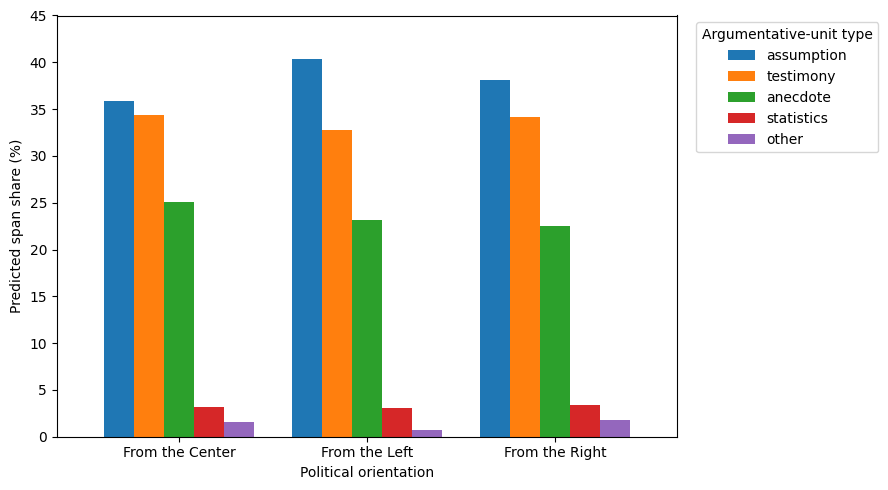

In [38]:
ax = orientation_label_distribution.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.8,
)

ax.set_xlabel("Political orientation")
ax.set_ylabel("Predicted span share (%)")
ax.set_xticklabels(
    orientation_label_distribution.index,
    rotation=0,
)
ax.set_ylim(0, 45)

ax.legend(
    title="Argumentative-unit type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "orientation_label_shares.pdf",
    bbox_inches="tight",
)

plt.show()

### 11.2 Predicted span density by political orientation

This figure shows the mean number of model-predicted argumentative-unit spans per 1,000 words for each AllSides political orientation category.

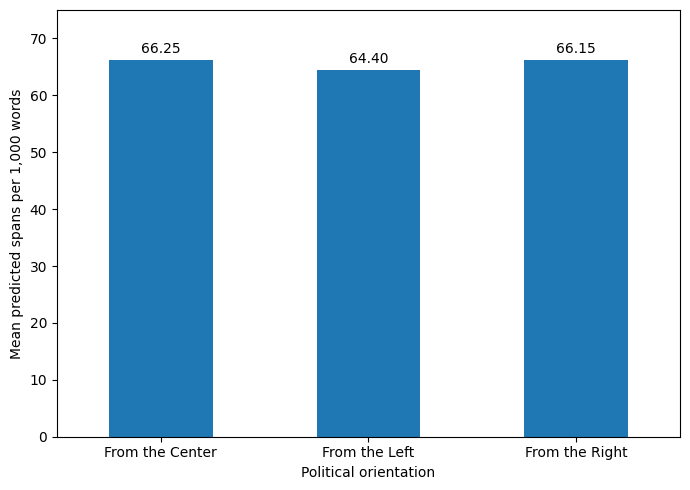

In [39]:
density_values = orientation_density.loc[
    ["From the Center", "From the Left", "From the Right"],
    "mean_spans_per_1000_words",
]

ax = density_values.plot(
    kind="bar",
    figsize=(7, 5),
)

ax.set_xlabel("Political orientation")
ax.set_ylabel("Mean predicted spans per 1,000 words")
ax.set_xticklabels(
    density_values.index,
    rotation=0,
)
ax.set_ylim(0, 75)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "orientation_span_density.pdf",
    bbox_inches="tight",
)

plt.show()

Predicted argumentative-unit density is broadly similar across political orientations. Center-leaning articles have the highest mean density (66.25 predicted spans per 1,000 words), followed closely by right-leaning articles (66.15), while left-leaning articles have a somewhat lower mean density (64.40).

### 11.3 Predicted label shares by topic

This figure shows the percentage distribution of model-predicted argumentative-unit labels across large topic categories. Only topics with at least 100 articles are included.

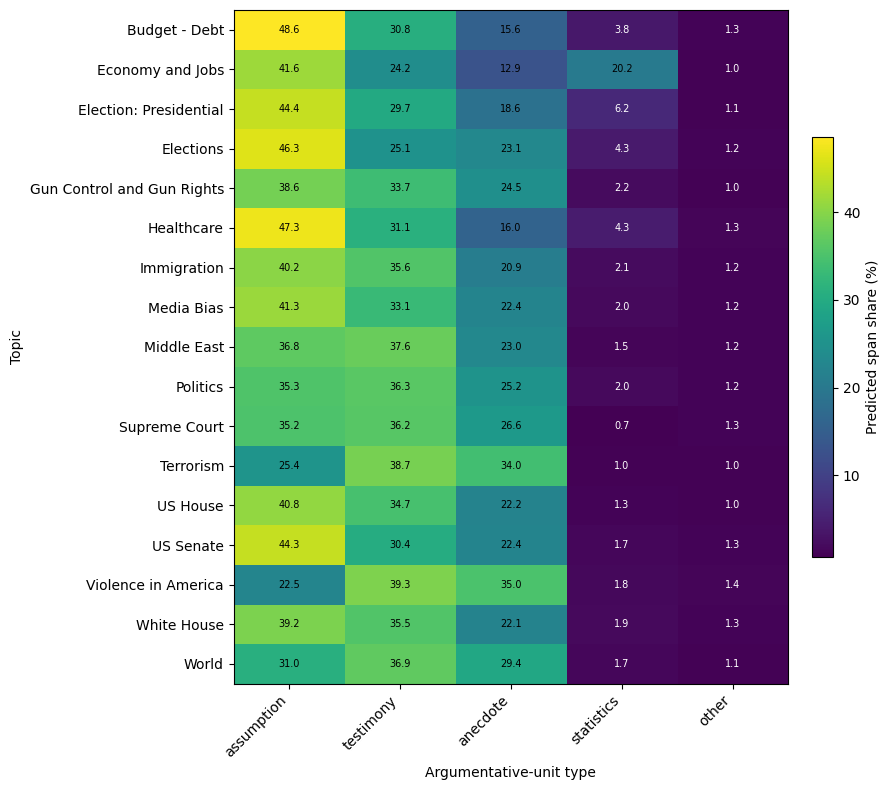

In [40]:
values = topic_label_distribution_wide[LABELS].values

fig, ax = plt.subplots(figsize=(9, 8))

image = ax.imshow(
    values,
    aspect="auto",
)

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=45, ha="right")

ax.set_yticks(range(len(topic_label_distribution_wide.index)))
ax.set_yticklabels(topic_label_distribution_wide.index)

ax.set_xlabel("Argumentative-unit type")
ax.set_ylabel("Topic")

cbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.04,
)
cbar.set_label("Predicted span share (%)")

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if value < 10 else "black",
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "topic_label_shares_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

### 11.4 Predicted span density by topic

This figure shows the mean number of model-predicted argumentative-unit spans per 1,000 words across topics with at least 100 articles.

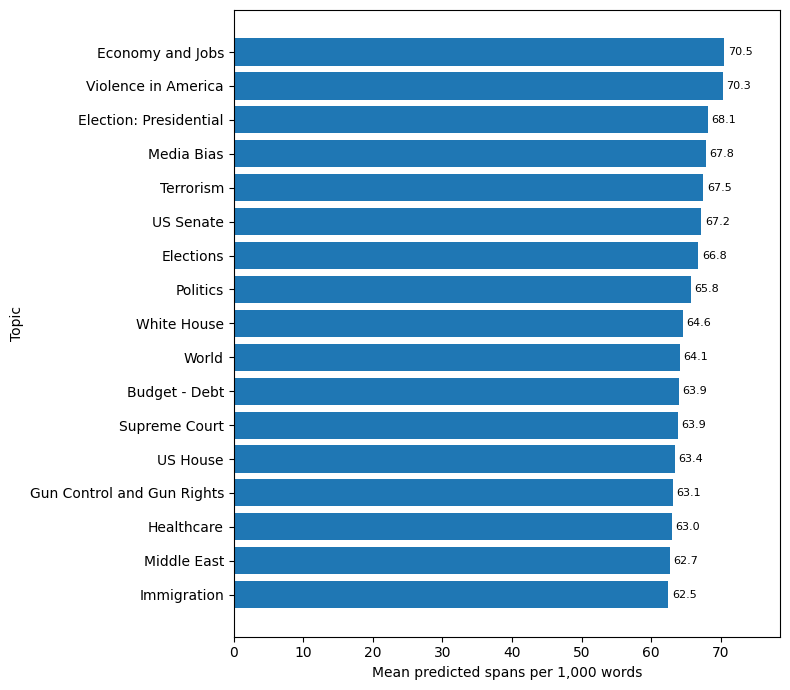

In [41]:
density_values = topic_density[
    "mean_spans_per_1000_words"
].sort_values()

fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.barh(
    density_values.index,
    density_values.values,
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=8,
    )

ax.set_xlabel("Mean predicted spans per 1,000 words")
ax.set_ylabel("Topic")
ax.set_xlim(0, density_values.max() + 8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "topic_span_density.pdf",
    bbox_inches="tight",
)

plt.show()

Predicted argumentative-unit density varies across topics, although the overall range is moderate. Economy and Jobs has the highest mean density (70.53 predicted spans per 1,000 words), followed closely by Violence in America (70.30). At the lower end, Immigration has the lowest mean density (62.48), followed by Middle East (62.67) and Healthcare (62.97). These results indicate meaningful descriptive variation across topics while showing that most topics remain within a relatively comparable overall density range.

### 11.5 Predicted Span Density by Source

This figure shows the mean number of model-predicted argumentative-unit spans per 1,000 words across the 27 news outlets retained in the source-level analysis.

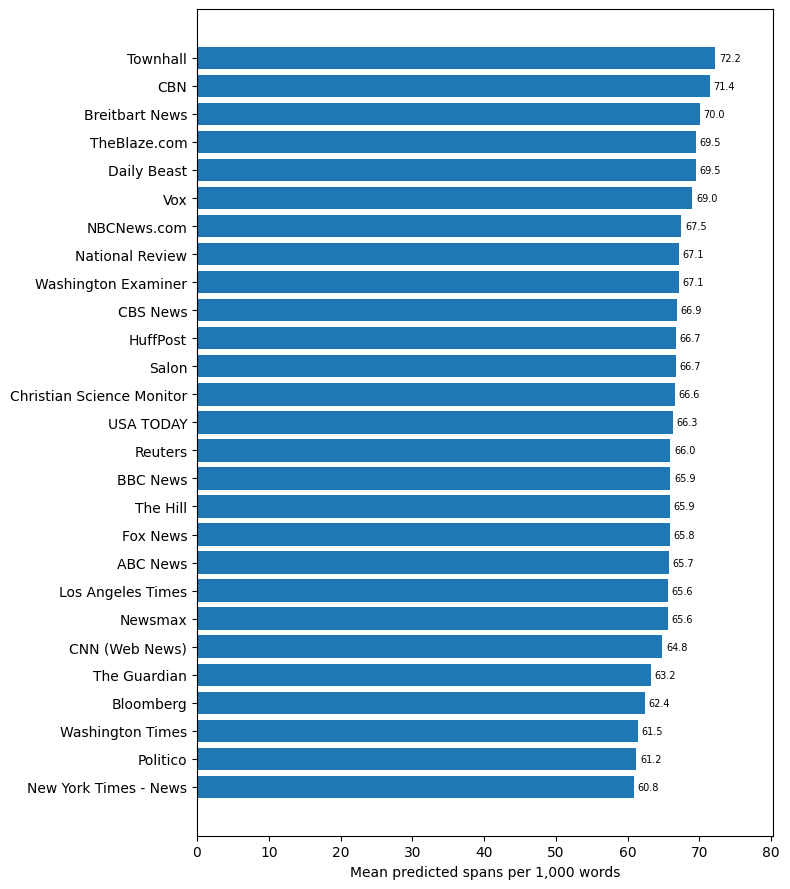

In [42]:
density_values = (
    source_density
    .set_index("source")["mean_spans_per_1000_words"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 9))

bars = ax.barh(
    density_values.index,
    density_values.values,
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=7,
    )

ax.set_xlabel("Mean predicted spans per 1,000 words")
ax.set_ylabel("")
ax.set_xlim(0, density_values.max() + 8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "source_span_density.pdf",
    bbox_inches="tight",
)

plt.show()

Predicted argumentative-unit density varies across news outlets. Townhall has the highest mean density (72.18 predicted spans per 1,000 words), followed by CBN (71.40) and Breitbart News (70.02). At the lower end, New York Times - News has the lowest mean density (60.84), followed by Politico (61.20) and Washington Times (61.45). The figure also shows considerable variation among outlets assigned to the same AllSides political-orientation category.

### 11.6 Argumentative-Unit Distribution by Outlet

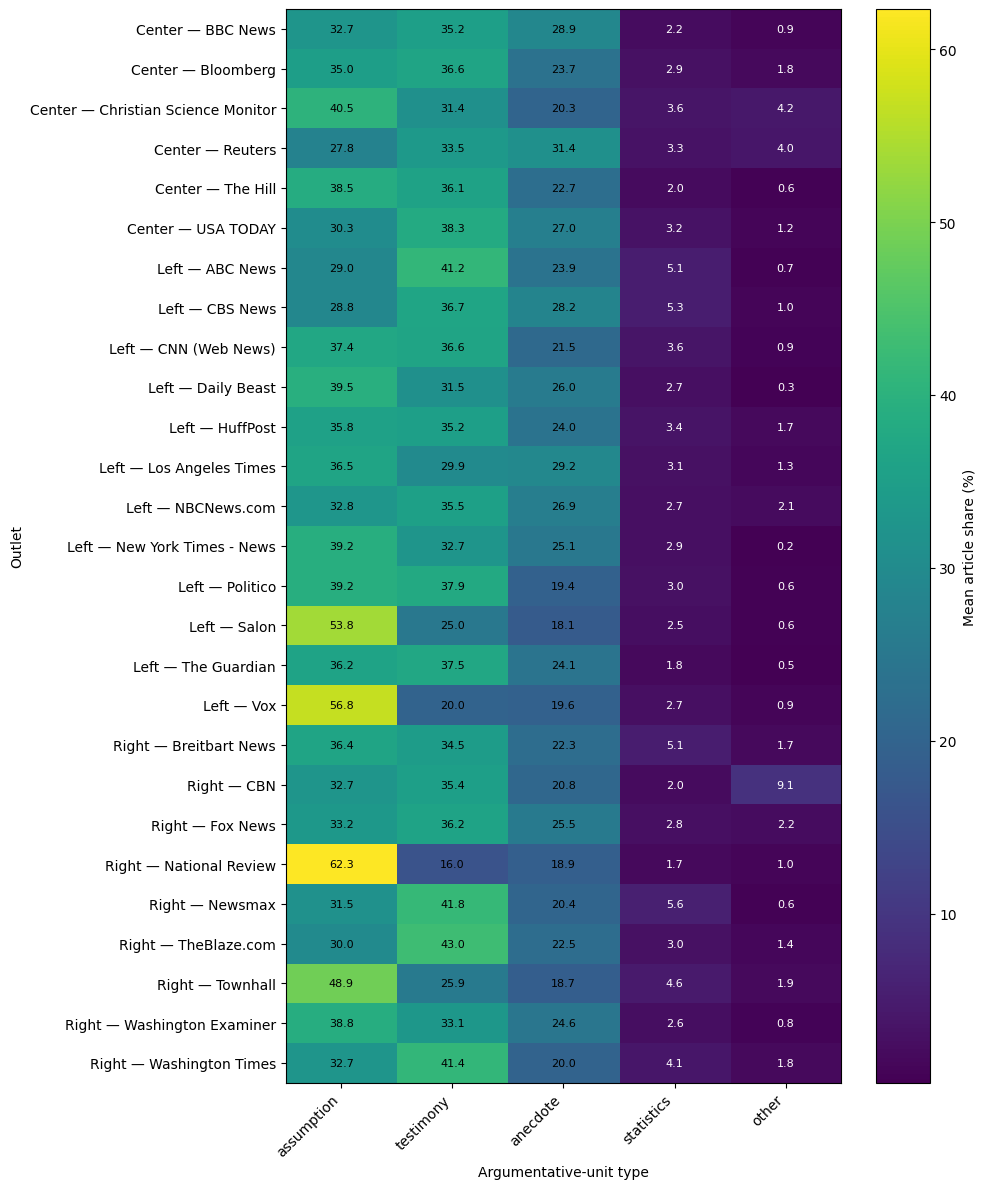

In [44]:
for label in LABELS:
    article_df[f"{label}_share"] = (
        article_df[f"{label}_count"]
        / article_df["total_predicted_spans"]
    )
    
outlet_heatmap = (
    article_df[
        article_df["source"].isin(retained_sources)
    ]
    .groupby(["allsides_bias", "source"])[
        [
            "assumption_share",
            "testimony_share",
            "anecdote_share",
            "statistics_share",
            "other_share",
        ]
    ]
    .mean()
    * 100
)

outlet_heatmap = outlet_heatmap.loc[
    ["From the Center", "From the Left", "From the Right"]
]

outlet_heatmap.columns = [
    "assumption",
    "testimony",
    "anecdote",
    "statistics",
    "other",
]

outlet_heatmap.index = [
    f"{orientation.replace('From the ', '')} — {source}"
    for orientation, source in outlet_heatmap.index
]

fig, ax = plt.subplots(figsize=(10, 12))

image = ax.imshow(
    outlet_heatmap.values,
    aspect="auto",
    cmap="viridis",
)

ax.set_xticks(range(len(outlet_heatmap.columns)))
ax.set_xticklabels(
    outlet_heatmap.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(range(len(outlet_heatmap.index)))
ax.set_yticklabels(outlet_heatmap.index)

ax.set_xlabel("Argumentative-unit type")
ax.set_ylabel("Outlet")

for i in range(len(outlet_heatmap)):
    for j in range(len(outlet_heatmap.columns)):
        value = outlet_heatmap.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="black" if value > 15 else "white",
            fontsize=8,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Mean article share (%)")

plt.tight_layout()

plt.savefig(
    "../figures/nlpcss20_outlet_argumentative_unit_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

The outlet-level heatmap shows substantial variation in argumentative-unit composition across individual news outlets. Across most outlets, assumption, testimony, and anecdote account for the large majority of predicted spans, while statistics and especially other remain comparatively limited. At the same time, the figure also shows that some outlets display distinctive profiles. For example, several left- and right-leaning outlets show particularly high shares of assumption, whereas others show comparatively stronger testimony. This suggests that variation is not only structured by broad political orientation, but also by outlet-specific rhetorical tendencies.

## 12. Statistical Tests

Statistical tests are used to examine whether differences between center-, left-, and right-leaning articles are statistically significant. The article is treated as the unit of analysis.

In [ ]:
from scipy.stats import kruskal, mannwhitneyu

### 12.1 Predicted Span Density by Political Orientation

In [ ]:
center_density = article_df.loc[
    article_df["allsides_bias"] == "From the Center",
    "total_spans_per_1000_words",
].dropna()

left_density = article_df.loc[
    article_df["allsides_bias"] == "From the Left",
    "total_spans_per_1000_words",
].dropna()

right_density = article_df.loc[
    article_df["allsides_bias"] == "From the Right",
    "total_spans_per_1000_words",
].dropna()

density_test = kruskal(
    center_density,
    left_density,
    right_density,
)

print(f"Kruskal-Wallis H: {density_test.statistic:.3f}")
print(f"p-value: {density_test.pvalue:.13f}")

Kruskal-Wallis H: 42.883
p-value: 0.0000000004877


In [ ]:
pairwise_density_tests = [
    ("Center vs Left", center_density, left_density),
    ("Center vs Right", center_density, right_density),
    ("Left vs Right", left_density, right_density),
]

for comparison, group1, group2 in pairwise_density_tests:
    test = mannwhitneyu(group1, group2, alternative="two-sided")

    print(comparison)
    print(f"U: {test.statistic:.3f}")
    print(f"p-value: {test.pvalue:.13f}")
    print()

Center vs Left
U: 2409353.500
p-value: 0.0000000528892

Center vs Right
U: 1729163.000
p-value: 0.2960716574385

Left vs Right
U: 4659401.500
p-value: 0.0000001170242



In [ ]:
# %pip install statsmodels
from statsmodels.stats.multitest import multipletests

pairwise_density_results = []

for comparison, group1, group2 in pairwise_density_tests:
    test = mannwhitneyu(group1, group2, alternative="two-sided")

    pairwise_density_results.append(
        {
            "comparison": comparison,
            "U": test.statistic,
            "p_value": test.pvalue,
        }
    )

pairwise_density_results = pd.DataFrame(pairwise_density_results)

pairwise_density_results["p_value_corrected"] = multipletests(
    pairwise_density_results["p_value"],
    method="holm",
)[1]

for _, row in pairwise_density_results.iterrows():
    print(row["comparison"])
    print(f"U: {row['U']:.3f}")
    print(f"p-value: {row['p_value']:.13f}")
    print(f"Holm-corrected p-value: {row['p_value_corrected']:.13f}")
    print()

Center vs Left
U: 2409353.500
p-value: 0.0000000528892
Holm-corrected p-value: 0.0000001586677

Center vs Right
U: 1729163.000
p-value: 0.2960716574385
Holm-corrected p-value: 0.2960716574385

Left vs Right
U: 4659401.500
p-value: 0.0000001170242
Holm-corrected p-value: 0.0000002340484



In [ ]:
n_total = len(center_density) + len(left_density) + len(right_density)
k = 3

density_epsilon_squared = (
    density_test.statistic - k + 1
) / (n_total - k)

print(f"Epsilon-squared: {density_epsilon_squared:.4f}")

Epsilon-squared: 0.0054


In [ ]:
for comparison, group1, group2 in pairwise_density_tests:
    test = mannwhitneyu(group1, group2, alternative="two-sided")

    rank_biserial = (
        2 * test.statistic / (len(group1) * len(group2))
    ) - 1

    print(comparison)
    print(f"Rank-biserial correlation: {rank_biserial:.4f}")
    print()

Center vs Left
Rank-biserial correlation: 0.1044

Center vs Right
Rank-biserial correlation: 0.0208

Left vs Right
Rank-biserial correlation: -0.0771



### 12.2 Argumentative-Unit Composition by Political Orientation

In [ ]:
composition_test_results = []

for label in LABELS:
    center = article_df.loc[
        article_df["allsides_bias"] == "From the Center",
        f"{label}_share",
    ].dropna()

    left = article_df.loc[
        article_df["allsides_bias"] == "From the Left",
        f"{label}_share",
    ].dropna()

    right = article_df.loc[
        article_df["allsides_bias"] == "From the Right",
        f"{label}_share",
    ].dropna()

    test = kruskal(center, left, right)

    composition_test_results.append(
        {
            "label": label,
            "H": test.statistic,
            "p_value": test.pvalue,
        }
    )

composition_test_results = pd.DataFrame(composition_test_results)

for _, row in composition_test_results.iterrows():
    print(row["label"])
    print(f"H: {row['H']:.3f}")
    print(f"p-value: {row['p_value']:.13f}")
    print()

assumption
H: 68.372
p-value: 0.0000000000000

testimony
H: 8.400
p-value: 0.0149935103929

anecdote
H: 74.467
p-value: 0.0000000000000

statistics
H: 10.115
p-value: 0.0063600540308

other
H: 408.813
p-value: 0.0000000000000



In [ ]:
composition_test_results["p_value_corrected"] = multipletests(
    composition_test_results["p_value"],
    method="holm",
)[1]

for _, row in composition_test_results.iterrows():
    p_value = (
        f"{row['p_value']:.13f}"
        if row["p_value"] >= 1e-13
        else "< 0.0000000000001"
    )

    corrected_p = (
        f"{row['p_value_corrected']:.13f}"
        if row["p_value_corrected"] >= 1e-13
        else "< 0.0000000000001"
    )

    print(row["label"])
    print(f"H: {row['H']:.3f}")
    print(f"p-value: {p_value}")
    print(f"Holm-corrected p-value: {corrected_p}")
    print()

assumption
H: 68.372
p-value: < 0.0000000000001
Holm-corrected p-value: < 0.0000000000001

testimony
H: 8.400
p-value: 0.0149935103929
Holm-corrected p-value: 0.0149935103929

anecdote
H: 74.467
p-value: < 0.0000000000001
Holm-corrected p-value: < 0.0000000000001

statistics
H: 10.115
p-value: 0.0063600540308
Holm-corrected p-value: 0.0127201080615

other
H: 408.813
p-value: < 0.0000000000001
Holm-corrected p-value: < 0.0000000000001



In [ ]:
composition_test_results["epsilon_squared"] = (
    composition_test_results["H"] - 3 + 1
) / (len(article_df) - 3)

for _, row in composition_test_results.iterrows():
    print(row["label"])
    print(f"Epsilon-squared: {row['epsilon_squared']:.4f}")
    print()

assumption
Epsilon-squared: 0.0087

testimony
Epsilon-squared: 0.0008

anecdote
Epsilon-squared: 0.0095

statistics
Epsilon-squared: 0.0011

other
Epsilon-squared: 0.0534



In [ ]:
composition_pairwise_results = []

for label in LABELS:
    groups = {
        "Center": article_df.loc[
            article_df["allsides_bias"] == "From the Center",
            f"{label}_share",
        ].dropna(),
        "Left": article_df.loc[
            article_df["allsides_bias"] == "From the Left",
            f"{label}_share",
        ].dropna(),
        "Right": article_df.loc[
            article_df["allsides_bias"] == "From the Right",
            f"{label}_share",
        ].dropna(),
    }

    comparisons = [
        ("Center vs Left", groups["Center"], groups["Left"]),
        ("Center vs Right", groups["Center"], groups["Right"]),
        ("Left vs Right", groups["Left"], groups["Right"]),
    ]

    label_results = []

    for comparison, group1, group2 in comparisons:
        test = mannwhitneyu(group1, group2, alternative="two-sided")

        rank_biserial = (
            2 * test.statistic / (len(group1) * len(group2))
        ) - 1

        label_results.append(
            {
                "label": label,
                "comparison": comparison,
                "U": test.statistic,
                "p_value": test.pvalue,
                "rank_biserial": rank_biserial,
            }
        )

    corrected_p = multipletests(
        [result["p_value"] for result in label_results],
        method="holm",
    )[1]

    for result, p_corrected in zip(label_results, corrected_p):
        result["p_value_corrected"] = p_corrected
        composition_pairwise_results.append(result)

composition_pairwise_results = pd.DataFrame(composition_pairwise_results)

composition_pairwise_results[
    ["label", "comparison", "U", "p_value", "p_value_corrected", "rank_biserial"]
].round(
    {
        "U": 3,
        "p_value": 13,
        "p_value_corrected": 13,
        "rank_biserial": 4,
    }
)

,label,comparison,U,p_value,p_value_corrected,rank_biserial
0,assumption,Center vs Left,1871528.0,1.000000e-13,4.000000e-13,-0.1421
1,assumption,Center vs Right,1619165.5,2.615988e-02,2.615988e-02,-0.0442
2,assumption,Left vs Right,5494868.0,1.195100e-09,2.390300e-09,0.0884
3,testimony,Center vs Left,2267900.5,3.926300e-02,7.852600e-02,0.0395
4,testimony,Center vs Right,1687988.5,8.582241e-01,8.582241e-01,-0.0035
5,testimony,Left vs Right,4857059.5,9.156640e-03,2.746992e-02,-0.0379
6,anecdote,Center vs Left,2491215.0,1.000000e-13,3.000000e-13,0.1419
7,anecdote,Center vs Right,1971314.5,0.000000e+00,0.000000e+00,0.1637
8,anecdote,Left vs Right,5211808.0,2.603585e-02,2.603585e-02,0.0324
9,statistics,Center vs Left,2174187.5,8.370708e-01,8.370708e-01,-0.0034


In [ ]:
composition_article_summary = (
    article_df.groupby("allsides_bias")[
        [f"{label}_share" for label in LABELS]
    ]
    .agg(["mean", "median"])
    .mul(100)
    .round(2)
)

composition_article_summary

assumption_share        testimony_share        anecdote_share  \
                            mean median            mean median           mean   
allsides_bias                                                                   
From the Center            34.68  33.33           34.95  35.29          25.70   
From the Left              39.42  37.23           33.75  34.03          22.73   
From the Right             37.29  33.33           35.02  35.52          22.14   

                       statistics_share        other_share         
                median             mean median        mean median  
allsides_bias                                                      
From the Center  24.44             2.97    0.0        1.70    0.0  
From the Left    21.14             3.24    0.0        0.86    0.0  
From the Right   20.59             3.55    0.0        2.00    0.0

In [ ]:
density_test_summary = pd.DataFrame(
    {
        "H": [density_test.statistic],
        "p_value": [density_test.pvalue],
        "epsilon_squared": [density_epsilon_squared],
    }
)

density_test_summary.to_csv(
    OUTPUT_DIR / "orientation_density_statistical_test.csv",
    index=False,
)

pairwise_density_results.to_csv(
    OUTPUT_DIR / "orientation_density_pairwise_tests.csv",
    index=False,
)

composition_test_results.to_csv(
    OUTPUT_DIR / "orientation_composition_statistical_tests.csv",
    index=False,
)

composition_pairwise_results.to_csv(
    OUTPUT_DIR / "orientation_composition_pairwise_tests.csv",
    index=False,
)

### 12.3 Outlet-Based Statistical Comparison

In [ ]:
outlet_comparison_df = (
    article_df[article_df["source"].isin(retained_sources)]
    .groupby(["source", "allsides_bias"], as_index=False)
    .agg(
        n_articles=("article_position", "size"),
        mean_density=("total_spans_per_1000_words", "mean"),
        assumption_share=("assumption_share", "mean"),
        testimony_share=("testimony_share", "mean"),
        anecdote_share=("anecdote_share", "mean"),
        statistics_share=("statistics_share", "mean"),
        other_share=("other_share", "mean"),
    )
)

print(f"Outlets: {len(outlet_comparison_df)}")
print(outlet_comparison_df["allsides_bias"].value_counts())

Outlets: 27
allsides_bias
From the Left      12
From the Right      9
From the Center     6
Name: count, dtype: int64


In [ ]:
# testing outlet span density
center_outlet_density = outlet_comparison_df.loc[
    outlet_comparison_df["allsides_bias"] == "From the Center",
    "mean_density",
]

left_outlet_density = outlet_comparison_df.loc[
    outlet_comparison_df["allsides_bias"] == "From the Left",
    "mean_density",
]

right_outlet_density = outlet_comparison_df.loc[
    outlet_comparison_df["allsides_bias"] == "From the Right",
    "mean_density",
]

outlet_density_test = kruskal(
    center_outlet_density,
    left_outlet_density,
    right_outlet_density,
)

print(f"Kruskal-Wallis H: {outlet_density_test.statistic:.3f}")
print(f"p-value: {outlet_density_test.pvalue:.4f}")

Kruskal-Wallis H: 3.285
p-value: 0.1935


In [ ]:
# calculate effect sizee
outlet_density_epsilon_squared = (
    outlet_density_test.statistic - 3 + 1
) / (len(outlet_comparison_df) - 3)

print(f"Epsilon-squared: {outlet_density_epsilon_squared:.4f}")

Epsilon-squared: 0.0535


In [ ]:
# same outlet test but for the arg units
outlet_composition_results = []

for label in LABELS:
    center = outlet_comparison_df.loc[
        outlet_comparison_df["allsides_bias"] == "From the Center",
        f"{label}_share",
    ]

    left = outlet_comparison_df.loc[
        outlet_comparison_df["allsides_bias"] == "From the Left",
        f"{label}_share",
    ]

    right = outlet_comparison_df.loc[
        outlet_comparison_df["allsides_bias"] == "From the Right",
        f"{label}_share",
    ]

    test = kruskal(center, left, right)

    outlet_composition_results.append(
        {
            "label": label,
            "H": test.statistic,
            "p_value": test.pvalue,
        }
    )

outlet_composition_results = pd.DataFrame(outlet_composition_results)

outlet_composition_results["p_value_corrected"] = multipletests(
    outlet_composition_results["p_value"],
    method="holm",
)[1]

outlet_composition_results.round(
    {
        "H": 3,
        "p_value": 4,
        "p_value_corrected": 4,
    }
)

,label,H,p_value,p_value_corrected
0,assumption,1.376,0.5026,1.0000
1,testimony,0.256,0.8800,1.0000
2,anecdote,4.258,0.1189,0.4757
3,statistics,0.183,0.9126,1.0000
4,other,6.194,0.0452,0.2260


In [ ]:
# outlet effect size
outlet_composition_results["epsilon_squared"] = outlet_composition_results["H"].apply(
    lambda h: max(0, (h - 3 + 1) / (len(outlet_comparison_df) - 3))
)

outlet_composition_results.round(
    {
        "H": 3,
        "p_value": 4,
        "p_value_corrected": 4,
        "epsilon_squared": 4,
    }
)

,label,H,p_value,p_value_corrected,epsilon_squared
0,assumption,1.376,0.5026,1.0000,0.0000
1,testimony,0.256,0.8800,1.0000,0.0000
2,anecdote,4.258,0.1189,0.4757,0.0941
3,statistics,0.183,0.9126,1.0000,0.0000
4,other,6.194,0.0452,0.2260,0.1747


In [ ]:
outlet_density_summary = pd.DataFrame(
    {
        "H": [outlet_density_test.statistic],
        "p_value": [outlet_density_test.pvalue],
        "epsilon_squared": [outlet_density_epsilon_squared],
    }
)

outlet_density_summary.to_csv(
    OUTPUT_DIR / "outlet_density_statistical_test.csv",
    index=False,
)

outlet_composition_results.to_csv(
    OUTPUT_DIR / "outlet_composition_statistical_tests.csv",
    index=False,
)